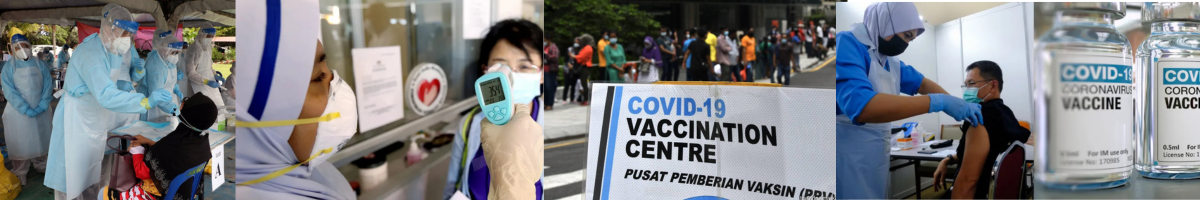

#**Exploratory Data Analysis of COVID-19 Trends in Malaysia**
*An analysis of case trends, mortality, and vaccination patterns using Malaysia Ministry of Health data*

## **1. Introduction**
COVID-19 pandemic has significantly affected public health systems and socio-economic conditions worldwide, including Malaysia. Our country had experienced multiple waves of infection, which placed considerable pressure on healthcare resources such as hospitals and intensive care units.

Analysing COVID-19 data help to understand how the pandemic evolved over time and for assessing the impact of public health interventions particularly on vaccination efforts. Examining trends in cases, deaths and vaccination coverage will provide useful insights on the effectiveness of these measures.

This study conducts an exploratory data analysis using publicly available datasets from the Ministry of Health Malaysia (MoH).Datasets include information such as daily cases, state-level distribution and vaccination progress.

The aim of this analysis is to identify key patterns and trends in COVID-19 data in Malaysia also to derive insights that may support a better understanding of the pandemic and how it can be managed in the future

**Dataset Source:**  
Ministry of Health Malaysia COVID-19 Open Data
  https://github.com/MoH-Malaysia/covid19-public

##**2. Problem Statement**
This study aims to address the following research questions:

1. How have COVID-19 cases evolved over time in Malaysia?
2. Which states have recorded the highest number of cases and deaths?
3. Is there a relationship between vaccination rates and the reduction of COVID-19 cases?
4. Which age groups are most affected by COVID-19?


##**3. Data Collection and Import**

In this section, dataset imported using Pandas library, as all data are in CSV format. The `read_csv()` function was used to load each file into the analysis environment.

A simple check was then carried out using the `head()` function to view the first few rows of the data. This step helps to understand the basic structure of the dataset before moving on to data cleaning process.

In [2]:
#Import library

import pandas as pd

In [4]:
#Upload data

from google.colab import files
uploaded = files.upload()

Saving cases_malaysia.csv to cases_malaysia.csv
Saving cases_state.csv to cases_state.csv
Saving deaths_malaysia.csv to deaths_malaysia.csv
Saving vax_demog_age.csv to vax_demog_age.csv
Saving vax_state.csv to vax_state.csv


In [5]:
#Load data

cases = pd.read_csv('cases_malaysia.csv')
state = pd.read_csv('cases_state.csv')
vax = pd.read_csv('vax_state.csv')
deaths = pd.read_csv('deaths_malaysia.csv')
vaxage = pd.read_csv('vax_demog_age.csv')

In [33]:
#Preview data

print("=== CASES ===")
print(cases.head())

print("\n=== STATE ===")
print(state.head())

print("\n=== VACCINATION ===")
print(vax.head())

print("\n=== DEATHS ===")
print(deaths.head())

print("\n=== EXTRA DATA ===")
print(vaxage.head())


=== CASES ===
         date  cases_new  cases_import  cases_recovered  cases_active  \
0  2020-01-25          4             4                0             4   
1  2020-01-26          0             0                0             4   
2  2020-01-27          0             0                0             4   
3  2020-01-28          0             0                0             4   
4  2020-01-29          3             3                0             7   

   cases_cluster  cases_unvax  cases_pvax  cases_fvax  cases_boost  ...  \
0              0            4           0           0            0  ...   
1              0            0           0           0            0  ...   
2              0            0           0           0            0  ...   
3              0            0           0           0            0  ...   
4              0            3           0           0            0  ...   

   cases_60_69  cases_70_79  cases_80  cluster_import  cluster_religious  \
0            0      

##**4. Data Cleaning**

In this step, data cleaning was performed to improve the quality and consistency of the datasets. The `date` column was converted into datetime format to allow proper time based analysis.

Missing values were handled using the `fillna(0)` function, as most of the missing entries represent zero reported cases. Duplicate rows were also removed to ensure the accuracy of the data.

Additionally, columns with a large number of missing values, especially cluster-related variables, were removed as they were not relevant to the objectives of this analysis. These steps help to ensure the data is clean and suitable for further analysis.

In [6]:
#Convert Date Format

cases['date'] = pd.to_datetime(cases['date'])
state['date'] = pd.to_datetime(state['date'])
vax['date'] = pd.to_datetime(vax['date'])
deaths['date'] = pd.to_datetime(deaths['date'])
vaxage['date'] = pd.to_datetime(vaxage['date'])

In [7]:
#Check Missing Values

print(cases.isnull().sum())
print(state.isnull().sum())
print(vax.isnull().sum())
print(deaths.isnull().sum())
print(vaxage.isnull().sum())

date                          0
cases_new                     0
cases_import                  0
cases_recovered               0
cases_active                  0
cases_cluster                 0
cases_unvax                   0
cases_pvax                    0
cases_fvax                    0
cases_boost                   0
cases_child                   0
cases_adolescent              0
cases_adult                   0
cases_elderly                 0
cases_0_4                     0
cases_5_11                    0
cases_12_17                   0
cases_18_29                   0
cases_30_39                   0
cases_40_49                   0
cases_50_59                   0
cases_60_69                   0
cases_70_79                   0
cases_80                      0
cluster_import             1954
cluster_religious          1954
cluster_community          1954
cluster_highRisk           1954
cluster_education          1954
cluster_detentionCentre    1954
cluster_workplace          1954
dtype: i

In [8]:
#Handle missing values

cases = cases.fillna(0)
state = state.fillna(0)
vax = vax.fillna(0)
deaths = deaths.fillna(0)
vaxage = vaxage.fillna(0)

In [9]:
#Remove duplicates

cases = cases.drop_duplicates()
state = state.drop_duplicates()
vax = vax.drop_duplicates()
deaths = deaths.drop_duplicates()
vaxage = vaxage.drop_duplicates()

In [10]:
#Drop unwanted column from dataset cases

cases = cases.drop(columns=[
    'cluster_import', 'cluster_religious',
    'cluster_community', 'cluster_highRisk',
    'cluster_education', 'cluster_detentionCentre',
    'cluster_workplace'
], errors='ignore')


In [11]:
#Final dataset check

cases.info()
state.info()
vax.info()
deaths.info()
vaxage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1954 entries, 0 to 1953
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1954 non-null   datetime64[ns]
 1   cases_new         1954 non-null   int64         
 2   cases_import      1954 non-null   int64         
 3   cases_recovered   1954 non-null   int64         
 4   cases_active      1954 non-null   int64         
 5   cases_cluster     1954 non-null   int64         
 6   cases_unvax       1954 non-null   int64         
 7   cases_pvax        1954 non-null   int64         
 8   cases_fvax        1954 non-null   int64         
 9   cases_boost       1954 non-null   int64         
 10  cases_child       1954 non-null   int64         
 11  cases_adolescent  1954 non-null   int64         
 12  cases_adult       1954 non-null   int64         
 13  cases_elderly     1954 non-null   int64         
 14  cases_0_4         1954 n

##**5. Data Visualization & Insights**

###📊**5.1 Covid-19 Cases Trend**

Dataframe was created to support the analysis of daily COVID-19 cases. Dataset was sorted by date and a 7 day moving average was calculated to smooth the short term fluctuations.

A preview of the dataframe is shown above, including the original daily cases and the computed moving average. Initial rows contain missing values for the moving average due to insufficient data points which is expected

In [26]:
#Select relevant columns
cases_trend = cases[['date', 'cases_new']]

#Sort by date (important for line graph)
cases_trend = cases_trend.sort_values('date')

#Optional: create 7-day moving average (lebih smooth)
cases_trend['cases_7d_avg'] = cases_trend['cases_new'].rolling(window=7).mean()

#Display result
pd.concat([cases_trend.head(10), cases_trend.tail(10)])


,date,cases_new,cases_7d_avg
0,2020-01-25,4,NaN
1,2020-01-26,0,NaN
2,2020-01-27,0,NaN
3,2020-01-28,0,NaN
4,2020-01-29,3,NaN
5,2020-01-30,1,NaN
6,2020-01-31,0,1.142857
7,2020-02-01,0,0.571429
8,2020-02-02,0,0.571429
9,2020-02-03,0,0.571429


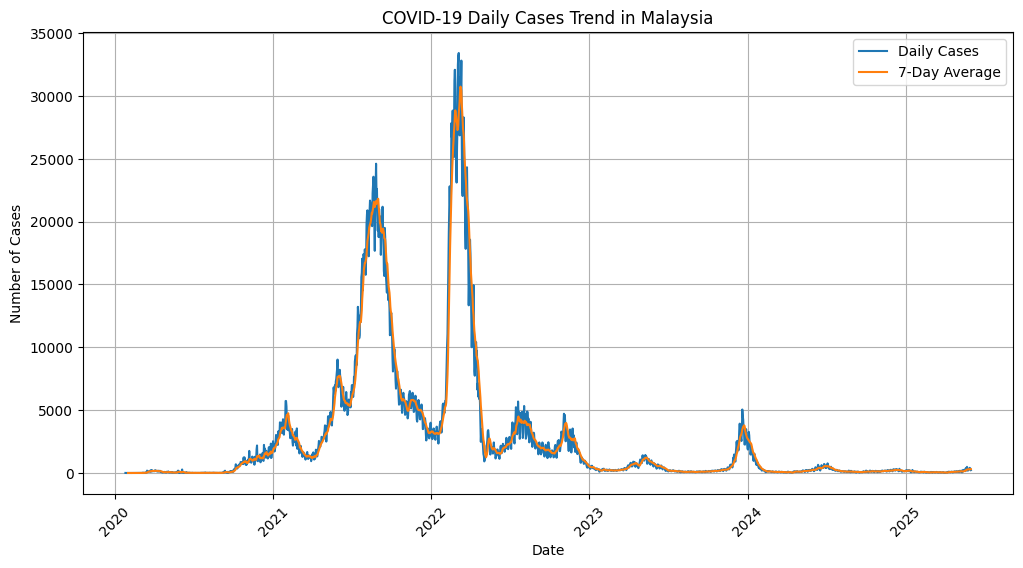

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Actual cases
sns.lineplot(x='date', y='cases_new', data=cases_trend, label='Daily Cases')

# Smoothed line
sns.lineplot(x='date', y='cases_7d_avg', data=cases_trend, label='7-Day Average')

plt.title('COVID-19 Daily Cases Trend in Malaysia')
plt.xlabel('Date')
plt.ylabel('Number of Cases')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()


Line chart above show a time series analysis of COVID-19 daily cases in Malaysia from 2020 to 2025. 7 day moving average is included to provide a smoother and clearer view of the overall pattern.

Chart shows several waves of infection over the years. There is a noticeable increase in cases around mid 2021, followed by a higher peak in early 2022, where the number of cases reached its maximum around 30000 to 35000 cases. These increases may be linked to more transmissable Covid-19 variants.

After 2022, the number of cases gradually decreased, with only smaller increases observed in between 2023 and 2025. This decline may be related to vaccination efforts and improved public health measures.It also reflect the effect of vaccination and increasing immunity within the Malaysian population.

Overall, graph clearly shows how COVID-19 cases changed over time in Malaysia, with periods of rapid increase followed by a gradual decline.

###📊**5.2 Covid-19 Cases by State**

Data was grouped by state to calculate the total number of COVID-19 cases in each state. The results were then sorted in descending order to identify the states with the highest number of cases.

In [27]:
#Group by state and sum total cases
state_cases = state.groupby('state')['cases_new'].sum().reset_index()

#Sort descending (negeri highest dulu)
state_cases = state_cases.sort_values(by='cases_new', ascending=False)

#Display result
state_cases

,state,cases_new
11,Selangor,1640294
13,W.P. Kuala Lumpur,526668
0,Johor,420476
9,Sabah,414623
10,Sarawak,335098
1,Kedah,333286
8,Pulau Pinang,325467
2,Kelantan,269231
6,Perak,251877
4,Negeri Sembilan,244989


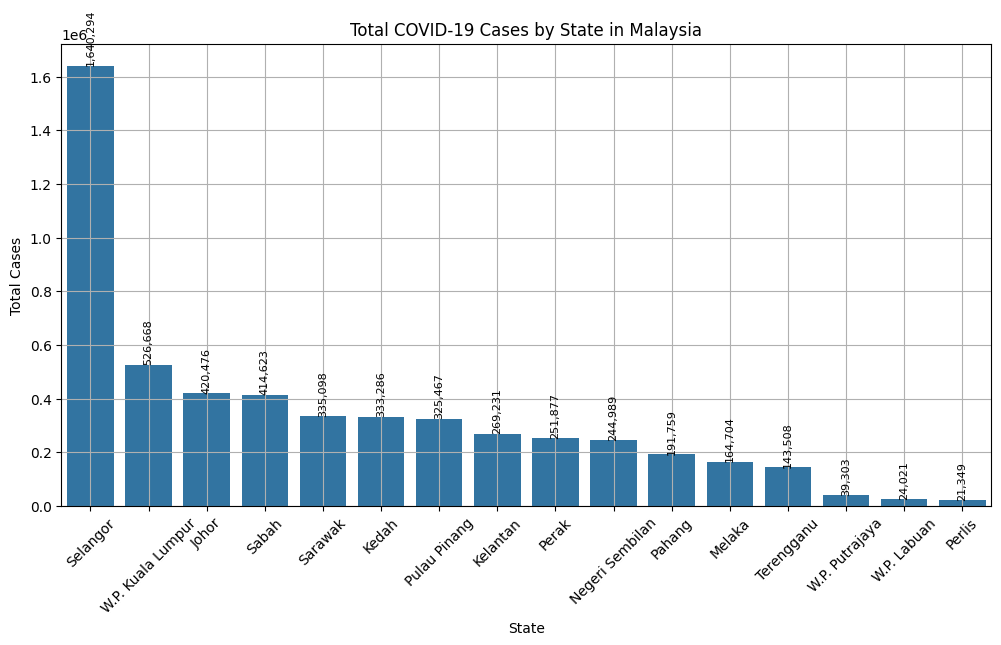

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.barplot(x='state', y='cases_new', data=state_cases)

for i, v in enumerate(state_cases['cases_new']):
    ax.text(
        i,
        v,
        f"{v:,.0f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.title('Total COVID-19 Cases by State in Malaysia')
plt.xlabel('State')
plt.ylabel('Total Cases')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()


Bar chart shows the total number of COVID-19 cases across different states in Malaysia from 2020 to 2025.

It can be seen that Selangor recorded the highest number of cases (1.640k), followed by W.P. Kuala Lumpur (527k) and Johor (420k). These states have higher population and are more urban areas which may lead to more transmission.

In contrast, states such as Perlis (21k), W.P. Labuan (24k), and W.P. Putrajaya (39k) reported much lower numbers of cases. This may be due to smaller populations and less crowded conditions.

Overall, the chart shows that COVID-19 cases are not evenly distributed across Malaysia, and factors such as population size and movement of people may influence the spread of the virus. Higher case numbers in some states may also be linked to higher economic activity and more daily interaction among people.

##📊**5.3 Vaccination vs Cases**
For this analysis, COVID-19 case data was combined with vaccination data using the date as a common variable. Relevant columns were selected, including daily cases and daily completed vaccinations.

Data was merged into a single dataframe to allow comparison between cases and vaccination trends over time. A 7 day moving average was applied to both variables to reduce short-term fluctuations and to highlight overall patterns.

In [17]:
#Select relevant columns
cases_vax = cases[['date', 'cases_new']]
vax_data = vax[['date', 'daily_full']]

#Merge by date
merged_vax = cases_vax.merge(vax_data, on='date', how='left')

#Sort by date
merged_vax = merged_vax.sort_values('date')

#Optional: smooth data
merged_vax['cases_7d_avg'] = merged_vax['cases_new'].rolling(7).mean()
merged_vax['vax_7d_avg'] = merged_vax['daily_full'].rolling(7).mean()

#Display result
pd.concat([merged_vax.head(10), merged_vax.tail(10)])

,date,cases_new,daily_full,cases_7d_avg,vax_7d_avg
0,2020-01-25,4,NaN,NaN,NaN
1,2020-01-26,0,NaN,NaN,NaN
2,2020-01-27,0,NaN,NaN,NaN
3,2020-01-28,0,NaN,NaN,NaN
4,2020-01-29,3,NaN,NaN,NaN
5,2020-01-30,1,NaN,NaN,NaN
6,2020-01-31,0,NaN,1.142857,NaN
7,2020-02-01,0,NaN,0.571429,NaN
8,2020-02-02,0,NaN,0.571429,NaN
9,2020-02-03,0,NaN,0.571429,NaN


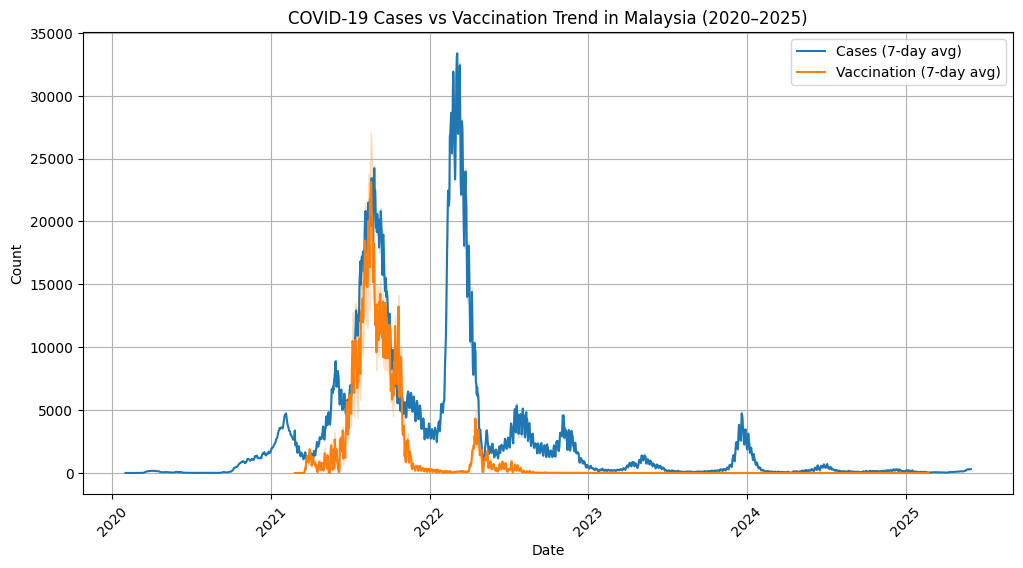

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

#Cases trend
sns.lineplot(x='date', y='cases_7d_avg', data=merged_vax, label='Cases (7-day avg)')

#Vaccination trend
sns.lineplot(x='date', y='vax_7d_avg', data=merged_vax, label='Vaccination (7-day avg)')

plt.title('COVID-19 Cases vs Vaccination Trend in Malaysia (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()


From the dual line chart above figure shows the trend of COVID-19 cases and vaccination in Malaysia from 2020 to 2025.

Vaccination started to increase in 2021 and at the same time, COVID-19 cases also increased and reached a peak in early 2022.

After this peak, the number of cases started to decrease, while vaccination levels stayed high. This suggests that vaccination may have helped to reduce the spread of COVID-19 over time.

However, cases still increased at the beginning even though vaccination had started. This may be because vaccines need time to build immunity in the population.

Overall, the graph shows a possible relationship between higher vaccination levels and lower COVID-19 cases in the later period. Vaccination helps the body build immunity, which can reduce the spread of the virus. This is also shows the importance of vaccination in controlling infectious diseases. This is supported by studies from the World Health Organization (WHO), which show that COVID-19 vaccination is effective in reducing severe illness, hospitalisation and death.



**References:**

World Health Organization.*Immunization Analysis and Insights*. Retrieved June 15, 2026 from https://www.who.int/teams/immunization-vaccines-and-biologicals/immunization-analysis-and-insights/surveillance/covid-19-vaccine-effectiveness-and-impact

##📊**5.4 Death Rate Trend**

For this section, death data was prepared by selecting the daily reported COVID-19 deaths and dataset was sorted by date to ensure proper time order. 7 day moving average was calculated to smooth the short-term fluctuations and to provide a clearer trend of death cases over time.

In [19]:
#Select relevant columns
deaths_trend = deaths[['date', 'deaths_new']]

#Sort by date
deaths_trend = deaths_trend.sort_values('date')

#Create 7-day moving average
deaths_trend['deaths_7d_avg'] = deaths_trend['deaths_new'].rolling(7).mean()

#Display result
pd.concat([deaths_trend.head(10), deaths_trend.tail(10)])

,date,deaths_new,deaths_7d_avg
0,2020-03-17,2,NaN
1,2020-03-18,0,NaN
2,2020-03-19,0,NaN
3,2020-03-20,1,NaN
4,2020-03-21,4,NaN
5,2020-03-22,4,NaN
6,2020-03-23,5,2.285714
7,2020-03-24,2,2.285714
8,2020-03-25,3,2.714286
9,2020-03-26,5,3.428571


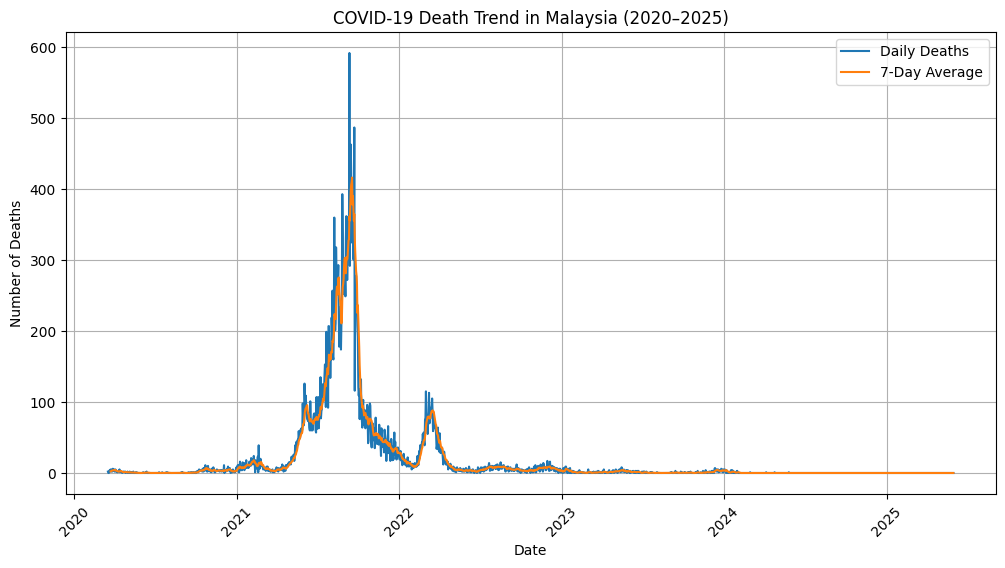

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

#Actual deaths
sns.lineplot(x='date', y='deaths_new', data=deaths_trend, label='Daily Deaths')

#Smoothed line
sns.lineplot(x='date', y='deaths_7d_avg', data=deaths_trend, label='7-Day Average')

plt.title('COVID-19 Death Trend in Malaysia (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()


Figure shows the trend of COVID-19 deaths in Malaysia from 2020 to 2025.

At the beginning of the pandemic in 2020, the number of deaths was low. Number then increased in 2021 and reached the highest level in early 2022.

After that, the number of deaths started to decrease and stayed low from 2023 to 2025.

Overall, the trend of deaths follows the trend of COVID-19 cases, where more cases lead to more deaths. It shows that severe infections can cause more deaths, especially during peak periods. This may be because COVID-19 can cause serious health problems, especially for older people and those with existing health conditions.

##📊**5.5 Age Group Distribution**

This analysis was to identify which age groups are most affected by COVID-19. Age related vaccination data was used to examine the distribution across different age groups. Relevant columns representing different age groups were selected and aggregated.

Total values were calculated for each age group to identify which group was most affected and this allows for comparison across age categories.

In [21]:
#Select relevant age columns (example grouping)
age_data = vaxage[[
    'date',
    'partial_18_29', 'partial_30_39', 'partial_40_49',
    'partial_50_59', 'partial_60_69', 'partial_70_79', 'partial_80'
]]

#Sum all values (total cases by age group)
age_totals = age_data.drop('date', axis=1).sum().reset_index()

#Rename columns
age_totals.columns = ['age_group', 'total_cases']

#Clean age group names
age_totals['age_group'] = age_totals['age_group'].str.replace('partial_', '')

#Display result
age_totals

,age_group,total_cases
0,18_29,6835127
1,30_39,5405400
2,40_49,4042984
3,50_59,3087292
4,60_69,2177057
5,70_79,992308
6,80,328730


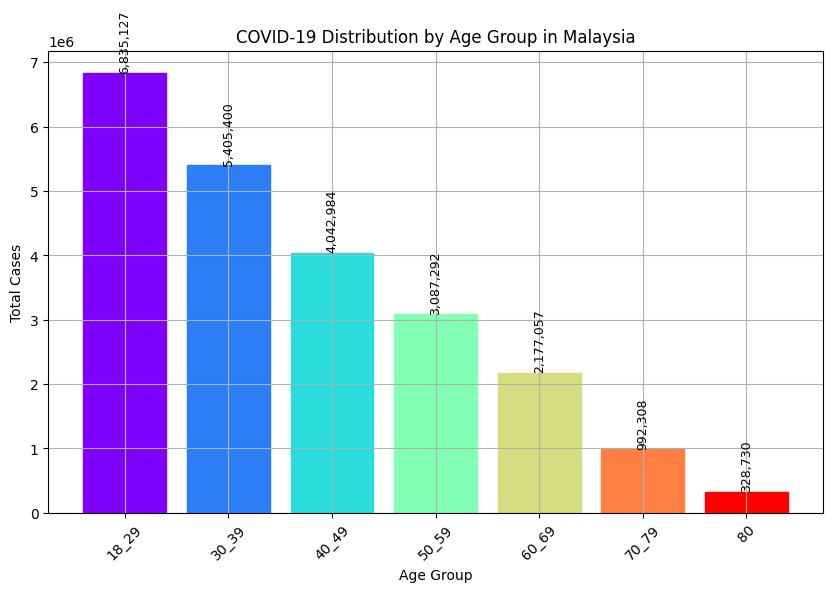

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values = age_totals['total_cases']
labels = age_totals['age_group']

# Create positions
x = np.arange(len(values))

# Create rainbow colors
colors = plt.cm.rainbow(np.linspace(0, 1, len(values)))

plt.figure(figsize=(10,6))

# Plot "histogram-style" bars
bars = plt.bar(x, values)

# Apply rainbow colors
for i in range(len(bars)):
    bars[i].set_color(colors[i])

# Apply value on bar
for i in range(len(values)):
    plt.text(
        x[i],
        values[i],
        f"{values[i]:,.0f}",   # format number with comma
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

# Labels
plt.title('COVID-19 Distribution by Age Group in Malaysia')
plt.xlabel('Age Group')
plt.ylabel('Total Cases')

plt.xticks(x, labels, rotation=45)
plt.grid(True)

plt.show()



Bar chart shows the distribution of COVID-19 cases across different age groups in Malaysia from 2020 to 2025.

The highest number of cases is seen in the 18-29 age group, followed by those aged 30-39 and 40-49. These groups represent working age adults, who are generally more active and have more daily interactions, which may increase their exposure to the virus spreading.

On the other hand, older age groups 70-79 and 80 recorded lower total cases. This may be due to smaller population size and more cautious behaviour.

Overall, chart shows that younger and middle-aged adults were the most affected in terms of total cases, although older individuals may have higher health risks if infected. Older individuals are more vulnerable to severe illness due to their immune system is weaker and more likely to have underlying health conditions.


##**6. Discussion**


This study analysed COVID-19 data in Malaysia from 2020 to 2025, focusing on trends in cases, deaths, vaccination and age group distribution. Coronavirus disease 2019 (COVID-19) emerged in late December 2019 and the World Health Organization (WHO) declared the end of the global health emergency on May 5, 2023. During this period, the disease resulted in 768 million cases and 6.94 million deaths worldwide [[1](https://news.un.org/en/story/2023/05/1136367),[2](https://data.who.int/dashboards/covid19/cases?n=c)]. In Malaysia, there have been more than 5 million COVID-19 cases and 37,000 fatalities to date [[3](https://data.moh.gov.my/)].

Results show that COVID-19 cases increased in several waves, with a major peak in early 2022. A similar pattern was observed in death trends, where higher numbers of cases were followed by an increase in deaths. This suggests a strong relationship between infection rates and mortality.

Analysis across states showed that Selangor, W.P. Kuala Lumpur, and Johor recorded the highest number of cases. These states are more urbanised and densely populated, which may increase the spread of the virus due to higher human interaction and mobility.

Vaccination trends indicate that vaccination levels increased significantly starting in 2021. Although cases continued to rise during the early stages of vaccination, a decline in cases was observed after the peak period which suggests that vaccination played an important role in reducing the spread of COVID-19 over time. This is supported by studies from the World Health Organization (WHO), which show that vaccination reduces severe illness and transmission.

Age group analysis showed that individuals aged from 18 to 59 recorded the highest number of cases. This group represents the working population, who are more exposed to social and work related environments. In contrast, older age groups recorded fewer cases but are more vulnerable to severe illness.

Overall, the findings show that COVID-19 trends in Malaysia were influenced by several factors, including population density, mobility, vaccination coverage, and age-related vulnerability. These results highlight the importance of vaccination and targeted public health measures in controlling the spread of infectious diseases. Waves observed in the data may also be linked to the spread of variants such as Delta and Omicron, which are known to be more transmissible.

Findings are consistent with global observations, where vaccination and public health interventions have been shown to reduce transmission and severity of COVID-19.



**References:**

1.United Nations WHO chief declares end to COVID-19 as a global health emergency.(2023).Retrieved June 16, 2026 from: https://news.un.org/en/story/2023/05

2.World Health Organization WHO coronavirus (COVID-19) dashboard.(2020). Retrieved June 16, 2026 from: https://covid19.who.int/

3.Ministry of Health Malaysia COVID-19: the latest data on the pandemic in Malaysia. (2021). Retrieved June 16, 2026 from: https://data.moh.gov.my/

##**7. Conclusion**

In conclusion, COVID-19 trends in Malaysia were influenced by multiple factors, including population density, human behaviour, vaccination, and age. These findings highlight the importance of public health strategies, especially vaccination and protection of high-risk groups, in managing the impact of infectious diseases.These findings provide valuable insights for future public health planning and preparation.